### Import Libraries

In [43]:
import altair as alt
import numpy as np
import pandas as pd
import math
import matplotlib
import matplotlib.pyplot as plt
import re
import seaborn as sns
import statsmodels.tsa
import ast
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose

### Load Data

In [44]:
merged_monthly_salary = pd.read_parquet('gs://data-analyst-wage-trends/clean/merged_monthly_salaries.parquet')
merged_monthly_salary.head()

,state,date_time,salary_yearly,total_cost
0,AR,2022-12-31,122500.0,64790.3994
1,AR,2023-01-31,96500.0,64790.3994
2,AR,2023-02-28,93250.0,64790.3994
3,AR,2023-03-31,87500.0,64790.3994
4,AR,2023-04-30,85690.0,64790.3994


In [45]:
data_jobs = pd.read_parquet('gs://data-analyst-wage-trends/clean/data_jobs_cleaned.parquet')
data_jobs.head()

,title,company_name,location,salary_yearly,schedule_type,work_from_home,skillset,state
date_time,,,,,,,,
2023-08-04 03:00:13.797776,Data Analyst,Meta,Anywhere,122000.0,Full-time,True,"['tableau', 'r', 'python', 'sql']",Other
2023-08-04 03:00:13.797776,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,41600.0,Contractor,True,"['powerpoint', 'excel', 'power_bi']",Other
2023-08-04 03:00:13.797776,Data Analyst | Workforce Management,Krispy Kreme,United States,100000.0,Contractor,False,"['powerpoint', 'excel', 'outlook', 'word']",Other
2023-08-04 03:00:19.724974,Senior Data Analyst,Aquent,Anywhere,119100.8,Unknown,True,['sql'],Other
2023-08-04 03:00:19.724974,Mid-level Claims Data Analyst,CIBA Insurance Services,United States,110000.0,Full-time,False,"['excel', 'mssql', 'ssrs', 'sql']",Other


### Mapping Questions to Visualizations

1. How do cost-of-living adjusted median salaries for Data Analysts vary across U.S. states in 2023?



In [46]:
# Ranked horizontal bar chart with a diverging color gradient to show differences in purchasing power for states
# Highlight regional variations/identify high-value locations

2. How did the median advertised salary for Data Analysts change from Nov 2022 to April 2025?

In [47]:
# Line graph including rolling median salary, and Box Plot for each quarter (to show change over time)
# Distinguish long-term salary trajectories from short-term volatility

3. How do salaries differ across seniority levels?

In [48]:
# Box plot displaying statistical summary for senior and non-senior roles
# Understand salary progression from non-senior to senior roles

4. Do remote data analyst positions pay differently than onsite positions, and has this difference evolved?

In [49]:
# Gradient area chart with a zero reference line to highlight magnitude/trajectory of the wage disparity
# Visualize the shifting magnitude and direction of the remote-vs-onsite wage disparity

5. Are certain skills associated with higher or lower salaries?

In [50]:
# Violin plot for each skill to show the distribution of salaries
# Display the density/distribution of salaries across skills, identifying high-paying technical skills

6. Did the number of job posts for data analysts fluctuate over time, and if so, how did that affect pay scales?

In [51]:
# Multi line chart plotting salaries and number of data analyst job postings over time
# Identify correlations between market demand and advertised salaries

### Visualizations

#### 1. How do cost-of-living adjusted median salaries for Data Analysts vary across U.S. states in 2023?


In [52]:
merged_2023 = merged_monthly_salary[
    merged_monthly_salary['date_time'].dt.year == 2023
].copy()

In [53]:
merged_2023['real_salary_ratio'] = (
    merged_2023['salary_yearly'] / merged_2023['total_cost']
)

We calculated the real_salary_ratio to fairly compare purchasing power across various geographic locations by normalizing incomes against the actual cost of living. It essentially indicates where a data analyst's compensation goes the furthest, regardless of the raw cash amount, by showing how many "units" of local living expenditures a salary can cover. A greater ratio denotes a more advantageous economic climate in which the pay greatly surpasses the state's base cost of living.

In [54]:
real_salary_by_state_2023 = (
    merged_2023
    .groupby('state', as_index=False)['real_salary_ratio']
    .median()
    .sort_values('real_salary_ratio', ascending=False)
)

In [55]:
bar_chart = (
    alt.Chart(real_salary_by_state_2023)
    .mark_bar()
    .encode(
        y=alt.Y(
            'state:N',
            sort='-x',
            title='State'
        ),
        x=alt.X(
            'real_salary_ratio:Q',
            title='Median Salary ÷ Cost of Living (2023)'
        ),
        color=alt.Color(
            'real_salary_ratio:Q',
            scale=alt.Scale(
                domain=[real_salary_by_state_2023['real_salary_ratio'].min(),
                        1,
                        real_salary_by_state_2023['real_salary_ratio'].max()],
                range=['#C62828', '#FDD835', '#2E7D32']
            ),
            legend=alt.Legend(title='Salary / COL Ratio')
        ),
        tooltip=[
            alt.Tooltip('state:N', title='State'),
            alt.Tooltip('real_salary_ratio:Q', title=' Adjusted Salary Ratio', format='.2f')
        ]
    )
    .properties(
        width=750,
        height=400,
        title='Cost-of-Living Adjusted Median Data Analyst Salaries by State (2023)'
    )
)

# vertical reference line at 1
rule = alt.Chart(pd.DataFrame({'x': [1]})).mark_rule(
    strokeDash=[5,5],
    color='black'
).encode(
    x='x:Q'
)

(bar_chart + rule)

alt.LayerChart(...)

Since the question compares purchasing power among states in a single year rather than looking at patterns over time, we chose a ranked horizontal bar chart with a diverging color gradient. While the gradient centered at 1.0 graphically highlights how much each state's median pay surpasses or falls short of the annual cost of living, sorting the states from highest to lowest ratio makes relative differences instantly apparent. Viewers can immediately determine which states have positive purchasing power and which do not due to the vertical reference line at 1.

##### Observations

The findings indicate significant differences between the seven states in 2023. Texas has the highest cost-of-living-adjusted pay (around 1.5), followed by Arkansas and Kansas, which show that median earnings in those states easily surpass projected living expenses. Oklahoma and Nebraska are just above the threshold, Missouri is just below 1.0, and New Jersey has a substantially lower ratio (about 0.6), indicating that median advertised incomes do not meet expected yearly living expenditures. In this sample, purchasing power for data analysts seems to be highest in areas with lower costs and lowest in states with higher costs.

#### 2. How did the median advertised salary for Data Analysts change from Nov 2022 to April 2025?


##### Line Chart

In [56]:
salary_monthly_national = (
    merged_monthly_salary
    .groupby('date_time', as_index=False)['salary_yearly']
    .median()
    .sort_values('date_time')
)

In [57]:
salary_monthly_national['rolling_3m'] = (
    salary_monthly_national['salary_yearly']
    .rolling(window=3, center=True)
    .median()
)

To reduce short-term month-to-month noise and better illustrate the underlying salary trend, I included a 3-month centered rolling median. The time-series pattern becomes more consistent and comprehensible when a rolling median is used instead of a mean since it lessens the impact of extreme postings or outliers.

In [58]:
line_chart = (
    alt.Chart(salary_monthly_national)
    .transform_fold(
        ['salary_yearly', 'rolling_3m'],
        as_=['Series', 'Salary']
    )
    .transform_calculate(
        SeriesLabel="""
        datum.Series == 'salary_yearly'
        ? 'Monthly Median Salary'
        : 'Rolling 3-Month Median Salary'
        """
    )
    .mark_line()
    .encode(
        x=alt.X('date_time:T', title='Month'),
        y=alt.Y('Salary:Q', title='Median Advertised Salary (USD)'),
        color=alt.Color('SeriesLabel:N', title=''),
        tooltip=[
            alt.Tooltip('date_time:T', title='Month'),
            alt.Tooltip('salary_yearly:Q', title='Monthly Median Salary', format=',.0f'),
            alt.Tooltip('rolling_3m:Q', title='Rolling 3-Month Median Salary', format=',.0f')
        ]
    )
    .properties(
        width=800,
        height=400,
        title='Median Advertised Salary for Data Analysts (Nov 2022 – Apr 2025)'
    )
    .interactive()
)

line_chart


alt.Chart(...)

Over the investigated period, the median salary for data analysts fluctuated significantly, peaking at over \$100,000 between late 2022 and mid-2024 and falling to a low of about \$40,000 in early 2025. Around July 2023, a noticeable and steep reduction in advertised salaries started, and by October of the same year, the median had fallen below $50,000. A period of relative stability at a lower pay floor between late 2023 and early 2024 is revealed by the 3-month rolling average (blue line), which successfully smoothes out the dramatic monthly variations displayed by the orange line. The data shows another sharp decline in the most recent month depicted, April 2025, where the median salary fell sharply, despite a robust comeback throughout 2024.

##### Box and Whisker Plot

In [59]:
data_jobs['quarter'] = pd.PeriodIndex(data_jobs.index, freq='Q').to_timestamp()

In [60]:
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [61]:
chart = (
    alt.Chart(data_jobs)
    .mark_boxplot(size=20)
    .encode(
        x=alt.X('quarter:T', title='Quarter', axis=alt.Axis(format='%Y Q%q')),
        y=alt.Y('salary_yearly:Q', title='Advertised Salary')
    )
    .properties(
        width=850,
        height=400,
        title='Distribution of Advertised Data Analyst Salaries by Quarter (Nov 2022 – Apr 2025)'
    )
)
chart

alt.Chart(...)

According to this boxplot, median advertised salary declined through the end of 2023, hit a low in late 2023, and then gradually increased again into 2024 and early 2025. Even though the central tendency changed, the interquartile range stayed largely stable from quarter to quarter, indicating that the pay dispersion did not significantly compress or spread over time. A number of extremely high outliers are shown, particularly in mid-2023 and late-2024, suggesting that there are sporadic, exceptionally high-paying positions that would skew the mean but are isolated in this perspective.



##### Conclusion

Since our objective is to demonstrate how income levels changed over time for data analyst roles, and a time-series line graph makes trend direction instantly apparent, we decided to utilize the rolling median line chart. By reducing the short-term volatility caused by varying job postings, the smoothing makes it easier to see the larger decline in late 2023 and the rebound through 2024–2025. The line chart, as opposed to a boxplot, highlights turning points and temporal momentum, which are essential for comprehending salary progression.

#### 3. How do salaries differ across seniority levels?

In [62]:
# create a binary seniority flag from job title
data_jobs['seniority_group'] = data_jobs['title'].str.contains(
    r'\bsenior\b', case=False, na=False
).map({True: 'Senior', False: 'Non-Senior'})# Create a binary seniority flag from job title
data_jobs['seniority_group'] = data_jobs['title'].str.contains(
    r'\bsenior\b', case=False, na=False
).map({True: 'Senior', False: 'Non-Senior'})

In [63]:
# plot the box-and-whisker plot
alt.data_transformers.disable_max_rows()
boxplot = (
    alt.Chart(data_jobs)
    .mark_boxplot(size=30)
    .encode(
        x=alt.X('seniority_group:N', title='Seniority Group'),
        y=alt.Y('salary_yearly:Q', title='Advertised Salary (USD)')
    )
    .properties(
        width=650,
        height=400,
        title='Salary Distribution for Senior vs Non-Senior Roles'
    )
)
boxplot

alt.Chart(...)

In [64]:
# compare median salaries
median_salary_comparison = (
    data_jobs.groupby('seniority_group', as_index=False)['salary_yearly']
    .median()
    .sort_values('salary_yearly', ascending=False)
)

median_salary_comparison

,seniority_group,salary_yearly
1,Senior,104000.0
0,Non-Senior,85000.0


##### Observations

Across the dataset, roles containing the word “Senior” in the job title consistently show higher median advertised salaries than non-senior roles, which have a wider spread and greater upper-range earning potential. Senior roles also exhibit a heavier concentration of high-end outliers, reflecting the presence of specialized or leadership-oriented positions with substantially elevated compensation. In contrast, non-senior salaries appear more tightly clustered, indicating more standardized pay ranges and less variability across postings. This pattern reinforces the idea that career progression not only increases typical earnings but also expands the range of potential compensation outcomes. It is also important to note that non-senior roles have much more variability in terms of their salaries.

#### 4. Do remote data analyst positions pay differently than onsite positions, and has this difference evolved?

In [65]:
alt.data_transformers.disable_max_rows()
work_type = data_jobs.copy()

# create monthly timestamp for grouping
work_type['month'] = work_type.index.to_period('M').to_timestamp()

# monthly median salary by remote status
monthly = (
    work_type.groupby(['month', 'work_from_home'], as_index=False)['salary_yearly']
      .median()
)

In [66]:
monthly['work_mode'] = monthly['work_from_home'].map({True: 'Remote', False: 'Onsite'})

In [67]:
remote = (
    monthly[monthly['work_from_home'] == True][['month', 'salary_yearly']]
    .rename(columns={'salary_yearly': 'remote_median'})
)
onsite = (
    monthly[monthly['work_from_home'] == False][['month', 'salary_yearly']]
    .rename(columns={'salary_yearly': 'onsite_median'})
)


In [68]:
gap = remote.merge(onsite, on='month', how='inner')
gap['gap'] = gap['remote_median'] - gap['onsite_median']

We computed the gap variable to measure the monthly direct pay difference between onsite and remote data analyst positions. The "Remote Pay Premium" is represented by this number as a positive value denotes more compensation for remote work, while a negative number represents an onsite salary advantage. Additionally, we combined two distinct data series into a single statistic that clearly depicts the changing financial trade-offs of remote employment over time.

In [69]:
all_months = pd.date_range(gap["month"].min(), gap["month"].max(), freq="MS")
gap = (
    gap.set_index("month")
       .reindex(all_months)
       .rename_axis("month")
       .reset_index()
)

In [70]:
color_gradient = alt.Gradient(
    gradient='linear',
    stops=[
        alt.GradientStop(color='#C62828', offset=0), # Red
         # Switch to green
        alt.GradientStop(color='#2E7D32', offset=1)    # Green
    ],
    x1=1, x2=1, y1=1, y2=0
)

area = alt.Chart(gap).mark_area(
    opacity=0.7,
    line={'color': 'darkgray', 'width': 0.5},
    color=color_gradient,
    interpolate='linear'
).encode(
    x=alt.X('month:T', title='Month'),
    y=alt.Y('gap:Q', title='Remote − Onsite Median Salary (USD)'),
    tooltip=[
        alt.Tooltip('month:T', title='Month', format='%B %Y'),
        alt.Tooltip('remote_median:Q', title='Remote Median', format='$,.0f'),
        alt.Tooltip('onsite_median:Q', title='Onsite Median', format='$,.0f'),
        alt.Tooltip('gap:Q', title='Pay Gap', format='$,.0f')
    ]
)

# reference line
zero_line = alt.Chart(pd.DataFrame({'y':[0]})).mark_rule(strokeDash=[5,5]).encode(y='y:Q')



# labels
label_positive = alt.Chart(pd.DataFrame({
    'x':[gap['month'].min()],
    'y':[gap['gap'].max()],
    'text':['Higher Remote Salary']
})).mark_text(
    align='left',
    dx=5,
    dy=-10,
    fontSize=15,
    color='#2E7D32'
).encode(
    x='x:T',
    y='y:Q',
    text='text'
)

label_negative = alt.Chart(pd.DataFrame({
    'x':[gap['month'].min()],
    'y':[gap['gap'].min()],
    'text':['Higher Onsite Salary']
})).mark_text(
    align='left',
    dx=5,
    dy=15,
    fontSize=15,
    color='#C62828'
).encode(
    x='x:T',
    y='y:Q',
    text='text'
)


(area + zero_line + label_positive + label_negative).properties(
    width=850,
    height=350,
    title='Remote vs. Onsite Median Salaries from 2023 to 2025'
).interactive()

alt.LayerChart(...)

We chose a gradient area chart with a zero reference line to highlight the magnitude and trajectory of the wage disparity between onsite and remote positions over time. The chart establishes a distinct "center of gravity" by placing the visualization on a zero baseline, making it easy for viewers to discern between an onsite premium (red) and a remote pay premium (green). The goal is to simplify a complicated comparison into a single, easily understood metric to quickly spot volatility and changing market patterns.

##### Observations

For the majority of the time between November 2022 and April 2025, onsite salaries outperformed remote pay, with remote data analyst employment typically paying less than onsite roles. This salary disparity has varied significantly, reaching a peak in late 2024 when median onsite earnings were almost $50,000 higher than remote incomes. Additionally, remote roles briefly commanded a premium in late 2023, but the trend has evolved toward a consistent "onsite premium," despite a slight narrowing of the gap in early 2025.

#### 5. Are certain skills associated with higher or lower salaries?

In [71]:
def clean_skillset(val):
    if isinstance(val, list):
        return val
    if pd.isna(val) or val == '[]' or val == '':
        return []
    try:
        # tries to convert string representation of list to actual list
        return ast.literal_eval(val)
    except:
        # manually strip brackets and split by comma
        return [s.strip().replace("'", "").replace('"', "") for s in str(val).strip("[]").split(',') if s.strip()]

This function was added to deal with the skillset column, which at first holds data in the form of strings that resemble lists (['tableau', 'python']) rather than actual Python list objects. This  ensures that any faulty strings, empty values, or standard list representations are transformed into clean, iterable lists for them to be correctly "exploded" into separate rows for the violin plot.

In [72]:
skills_df = data_jobs.copy()

skills_df['skillset_cleaned'] = skills_df['skillset'].apply(clean_skillset)
df_exploded = skills_df.explode('skillset_cleaned')

In [73]:
# remove rows with no salary or no skill
df_exploded = df_exploded.dropna(subset=['salary_yearly', 'skillset_cleaned'])
df_exploded = df_exploded[df_exploded['skillset_cleaned'] != '']

In [74]:
# focus on the most common skills
top_skills = df_exploded['skillset_cleaned'].value_counts().nlargest(10).index.tolist()
df_plot = df_exploded[df_exploded['skillset_cleaned'].isin(top_skills)]

Many of the more than 100 skills in the dataset most likely have too few entries to depict correctly, and a violin plot needs multiple data points to construct a meaningful distribution shape. By selecting for the top ten most common skills, we ensure that the visualization is statistically significant and easy to read without overloading the chart.

In [75]:
violin_plot = alt.Chart(df_plot).transform_joinaggregate(
    # calculate the median salary per skill group
    median_salary='median(salary_yearly)',
    groupby=['skillset_cleaned']
).transform_density(
    'salary_yearly',
    as_=['salary_yearly', 'density'],
    groupby=['skillset_cleaned', 'median_salary']
).mark_area(orient='horizontal').encode(
    y=alt.Y('salary_yearly:Q', title='Yearly Salary ($)', scale=alt.Scale(domain=[20000, 250000], clamp=True)),
    x=alt.X(
        'density:Q',
        stack='center',
        impute=None,
        title=None,
        axis=alt.Axis(labels=False, values=[], ticks=False)
    ),
    color=alt.Color('skillset_cleaned:N', legend=None),
    tooltip=[
        alt.Tooltip('skillset_cleaned:N', title='Skill'),
        alt.Tooltip('median_salary:Q', title='Median Salary', format='$,.0f')
    ],
    column=alt.Column(
        'skillset_cleaned:N',
        header=alt.Header(
            title='Skills',
            labelOrient='bottom',
            labelAngle=-45,
            labelPadding=10,
            labelFontWeight='bold',
            titleFontSize=16,
            titleFontWeight='bold'
        )
    )
).properties(
    width=80,
    height=400,
    title='Salary Distribution by Frequent Skills'
).configure_facet(
    spacing=0
).configure_view(
    stroke=None
)

violin_plot.display()

alt.Chart(...)

We chose to answer this questions using a violin plot because it displays the complete probability density of earnings for every skill. This enables us to view not only the median and range but also the areas where the majority of job offers are concentrated. It effectively addresses our research question by visually ranking skills such as AWS, R, and Python as higher-paying than administrative tools like Excel.

##### Observations

The plot demonstrates that the highest median salary is at 105k for specialized technical tools like AWS, followed by R and Python at 100k. Conversely, the lower end of the wage range is linked to more generic administrative tools like Word, Excel, and PowerPoint, with Word having the lowest median salary at 75k. Although the majority of jobs fall between 70k and 120k, the wide distributions for most of the skills demonstrate a wide range of earning potential. This graphic demonstrates that proficiency with programming and cloud is a major factor in higher earnings when compared to regular office software.

###6. Did the number of job posts for data analysts fluctuate over time, and if so, how did that affect pay scales?

In [76]:
# counts how many job postings per month
monthly_job_counts = (
    data_jobs
    .resample('M')
    .size()
    .reset_index(name='job_count')
)

/tmp/ipython-input-376017988.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


In [77]:
# calculate average yearly salary
merged_monthly_salary['date_time'] = pd.to_datetime(merged_monthly_salary['date_time'])

monthly_salary = (
    merged_monthly_salary
    .groupby('date_time', as_index=False)
    .agg(avg_salary=('salary_yearly', 'mean'))
)

In [78]:
# create data frame by combining monthly job counts and salary
monthly_combined = pd.merge(
    monthly_job_counts,
    monthly_salary,
    on='date_time',
    how='inner'
)

In [79]:
# normalize data
plot_df = monthly_combined.copy()

plot_df['job_index'] = (
    plot_df['job_count'] / plot_df['job_count'].iloc[0] * 100
)

plot_df['salary_index'] = (
    plot_df['avg_salary'] / plot_df['avg_salary'].iloc[0] * 100
)

In [80]:
plot_df = monthly_combined.copy()

plot_df['job_index'] = plot_df['job_count'] / plot_df['job_count'].iloc[0] * 100
plot_df['salary_index'] = plot_df['avg_salary'] / plot_df['avg_salary'].iloc[0] * 100

plot_long = plot_df.melt(
    id_vars='date_time',
    value_vars=['job_index', 'salary_index'],
    var_name='metric',
    value_name='index_value'
)

plot_long['metric'] = plot_long['metric'].map({
    'job_index': 'Job Postings Index',
    'salary_index': 'Salary Index'
})

Since the question asks for the number of job postings overall we converted the postings to monthly hiring demand. This smooths short term noise. We also aggregated salary by month creating a national average salary per month since the question is asking for overall salery trends. It also allows for the salary data to be comparable to job postings count. After combining the datasets we then normalized the data because job counts and salaries are different units.

In [81]:
chart = alt.Chart(plot_long).mark_line(strokeWidth=3).encode(
    x=alt.X('date_time:T', title='Date'),
    y=alt.Y('index_value:Q', title='Index (Base = 100)'),
    color=alt.Color('metric:N', title='Metric'),
    tooltip=[
        alt.Tooltip('date_time:T', title='Date'),
        alt.Tooltip('metric:N', title='Metric'),
        alt.Tooltip('index_value:Q', title='Index', format='.1f')
    ]
).properties(
    width=700,
    height=400,
    title='Relative Change in Job Postings and Salaries Over Time'
)

chart

alt.Chart(...)

We chose a multi-line graph because we need to show how job postings and salaries change overtime and how those correlate. A line graph is helpful when showing temporal trends and fluctuations. Plotting both on the same graph makes it easier to see patterns.


##### Observations

The graphs shows that the job postings were highly volatile over time whereas salaries were more stable. In the early period, job postings increased dramatically, but then declined sharply and continued to go downward. On the other hand, the salary increased moderatly in the beginning, dipped in the middle, and then slowly recovered before falling slightly near the end. As job postings dropped, salaries did not decline proportionally. This shows that while hiring demand fluctuated significantly, pay scales were more resistant to the market swings.

### Analytical & Statistical Methods

Here are our 4 primary candidates for analyzing time series data:


*   Univariate Autoregressive Models (AutoReg): These models use seasonal factors and the variable's own historical data to predict its future values.
*   Exponential Smoothing (Holt-Winters): This technique is used to forecast and model data that shows distinct seasonal patterns and trends.
*   Stationarity Tests (ADF/KPSS): These statistical tests assess whether the mean and variance of salaries stay consistent over time.
*   Dynamic Regime Switching: These models are intended to represent time series that shift between various "regimes," or states, such as times when market volatility is high and low.





#### Seasonal Decomposition

The STL implementation dissects the median monthly wage into its most basic elements: seasonal variations, long-term trends, and unpredictability. Because it successfully separates the underlying salary rise from recurrent monthly hiring cycles, the STL (Seasonal-Trend decomposition using LOESS) method gives us a better picture of the true market trajectory. We can deseasonalize the data and provide more precise and consistent pay projections by recognizing these seasonal trends.

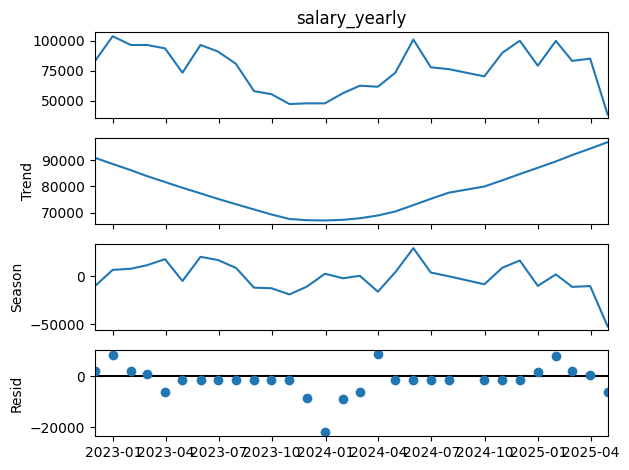

In [82]:
from statsmodels.tsa.seasonal import STL

ts = (
    merged_monthly_salary
    .groupby('date_time')['salary_yearly']
    .median()
    .sort_index()
)

stl = STL(ts, period=12)
result = stl.fit()

result.plot();


The analysis shows that changes in advertised Data Analyst wages between 2022 and 2025 were mostly caused by structural trend shifts rather than recurring seasonal cycles. After a gradual drop through 2023, salaries hit a low point in early 2024 before rising again in 2024–2025. The lack of seasonal effects suggests that labor market dynamics and macroeconomic variables were more important than regular yearly employment cycles.